# Gaming Industry Trends - Data Mining Analysis
## IHC Practical Approach to Data Mining and Analytics | Modular Assignment No. 1

**Dataset:** Gaming Industry Trends (1,000 records)  
**Techniques:** Classification, Clustering, Association Rules  
**Tools:** Python 3, pandas, scikit-learn, matplotlib, seaborn, mlxtend

---
# Phase 1: Data Acquisition & Initial Exploration

Data mining begins with understanding the raw data. In this phase we:
1. Load the dataset
2. Examine its structure
3. Identify data quality issues before any cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set consistent styling for all charts
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

# ── LOAD DATASET ──────────────────────────────────────────────
# UPDATE this path to wherever you saved the CSV file
df_raw = pd.read_csv("gaming_industry_trends.csv", encoding="latin-1")

print("Dataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("Column names:")
for col in df_raw.columns:
    print(f"  • {col}")

Dataset loaded successfully!
Shape: 1,000 rows × 11 columns
Column names:
  • Game Title
  • Genre
  • Platform
  • Release Year
  • Developer
  • Revenue (Millions $)
  • Players (Millions)
  • Peak Concurrent Players
  • Metacritic Score
  • Esports Popularity
  • Trending Status


In [2]:
# First look at the data
print("First 10 records:")
df_raw.head(10)

First 10 records:


,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable
5,Warzone Chronicles 3,Sports,Mobile,2022,Microsoft,763.43,189.18,50.51,78,Yes,Stable
6,Neon Speed 4,Strategy,Cross-Platform,2008,Sony,1415.65,110.52,30.57,78,No,Declining
7,Cyber Quest 3,Action,Mobile,2002,Ubisoft,1473.01,57.48,15.39,82,No,Declining
8,Warzone Chronicles 1,Adventure,Xbox,2003,Activision,752.25,192.70,71.06,92,Yes,Rising
9,Neon Speed 5,Sports,Mobile,2013,EA,4131.18,126.90,24.95,61,Yes,Rising


In [3]:
# Data types and basic statistics
print("Data Types:")
print(df_raw.dtypes)
print()
print("Basic Statistics (numeric columns):")
df_raw.describe().round(2)

Data Types:
Game Title                     str
Genre                          str
Platform                       str
Release Year                 int64
Developer                      str
Revenue (Millions $)       float64
Players (Millions)         float64
Peak Concurrent Players    float64
Metacritic Score             int64
Esports Popularity             str
Trending Status                str
dtype: object

Basic Statistics (numeric columns):


,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2012.07,2483.02,103.50,31.60,74.99
std,7.03,1412.63,58.87,23.02,14.62
min,2000.00,11.43,0.53,0.11,50.00
25%,2006.00,1276.19,52.00,12.97,62.00
50%,2012.00,2476.13,107.04,26.40,76.00
75%,2018.00,3677.80,155.63,46.02,87.00
max,2024.00,4999.79,199.98,96.62,100.00


---
# Phase 2: Data Preprocessing & Exploratory Data Analysis

Good preprocessing separates a reliable model from a misleading one.  
We assess quality, fix problems, encode categories, and visualise distributions.

In [4]:
# ── DATA QUALITY ASSESSMENT ──────────────────────────────────
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

# Missing values
missing = df_raw.isnull().sum()
print("\nMissing values per column:")
print(missing)

# Duplicates
dupes = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

# Trending Status breakdown (includes any unexpected values)
print("\nTrending Status categories:")
print(df_raw["Trending Status"].value_counts(dropna=False))

print("\nEsports Popularity categories:")
print(df_raw["Esports Popularity"].value_counts(dropna=False))

print("\nPlatform categories:")
print(df_raw["Platform"].value_counts())

print("\nGenre categories:")
print(df_raw["Genre"].value_counts())

DATA QUALITY REPORT

Missing values per column:
Game Title                 0
Genre                      0
Platform                   0
Release Year               0
Developer                  0
Revenue (Millions $)       0
Players (Millions)         0
Peak Concurrent Players    0
Metacritic Score           0
Esports Popularity         0
Trending Status            0
dtype: int64

Duplicate rows: 0

Trending Status categories:
Trending Status
Stable       339
Rising       335
Declining    326
Name: count, dtype: int64

Esports Popularity categories:
Esports Popularity
Yes    507
No     493
Name: count, dtype: int64

Platform categories:
Platform
PlayStation        175
PC                 174
Cross-Platform     168
Xbox               167
Mobile             158
Nintendo Switch    158
Name: count, dtype: int64

Genre categories:
Genre
Action        122
Strategy      116
Sports        116
Fighting      103
Shooter       100
Horror         96
Racing         95
Adventure      87
Simulation     8

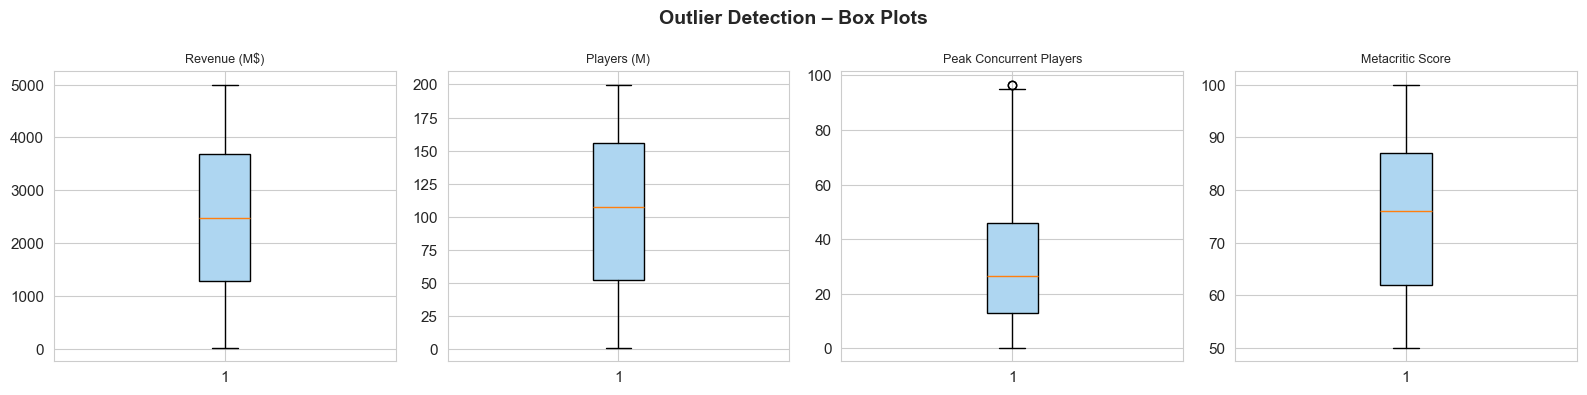

Observation: Revenue shows high variance — some AAA titles dwarf indie games.


In [5]:
# ── OUTLIER DETECTION ─────────────────────────────────────────
numeric_cols = ["Revenue (Millions $)", "Players (Millions)",
                "Peak Concurrent Players", "Metacritic Score"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Outlier Detection – Box Plots", fontsize=14, fontweight="bold")

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df_raw[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#AED6F1"))
    ax.set_title(col.replace(" (Millions $)", " (M$)")
                    .replace(" (Millions)", " (M)"), fontsize=9)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()
print("Observation: Revenue shows high variance — some AAA titles dwarf indie games.")

In [6]:
# ── PREPROCESSING ─────────────────────────────────────────────
df = df_raw.copy()

# Step 1: Remove duplicates (if any)
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Step 2: Encode binary column
df["Esports Popularity"] = df["Esports Popularity"].map({"Yes": 1, "No": 0})

# Step 3: Encode target with ALL 3 categories
df["Trending Status"] = df["Trending Status"].map({"Stable": 0, "Rising": 1, "Declining": 2})

# Step 4: One-hot encode Platform and Genre
df = pd.get_dummies(df, columns=["Platform", "Genre"], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print("\nTrending Status distribution:")
ts = df["Trending Status"].value_counts().sort_index()
labels = {0: "Stable", 1: "Rising", 2: "Declining"}
for k, v in ts.items():
    print(f"  {labels[k]}: {v} games")

print("\nAll columns:")
print(df.columns.tolist())

Duplicates removed: 0
Shape after encoding: (1000, 23)

Trending Status distribution:
  Stable: 339 games
  Rising: 335 games
  Declining: 326 games

All columns:
['Game Title', 'Release Year', 'Developer', 'Revenue (Millions $)', 'Players (Millions)', 'Peak Concurrent Players', 'Metacritic Score', 'Esports Popularity', 'Trending Status', 'Platform_Mobile', 'Platform_Nintendo Switch', 'Platform_PC', 'Platform_PlayStation', 'Platform_Xbox', 'Genre_Adventure', 'Genre_Fighting', 'Genre_Horror', 'Genre_RPG', 'Genre_Racing', 'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy']


## Exploratory Data Analysis (EDA)

Visualising distributions and relationships helps us form hypotheses before modelling.

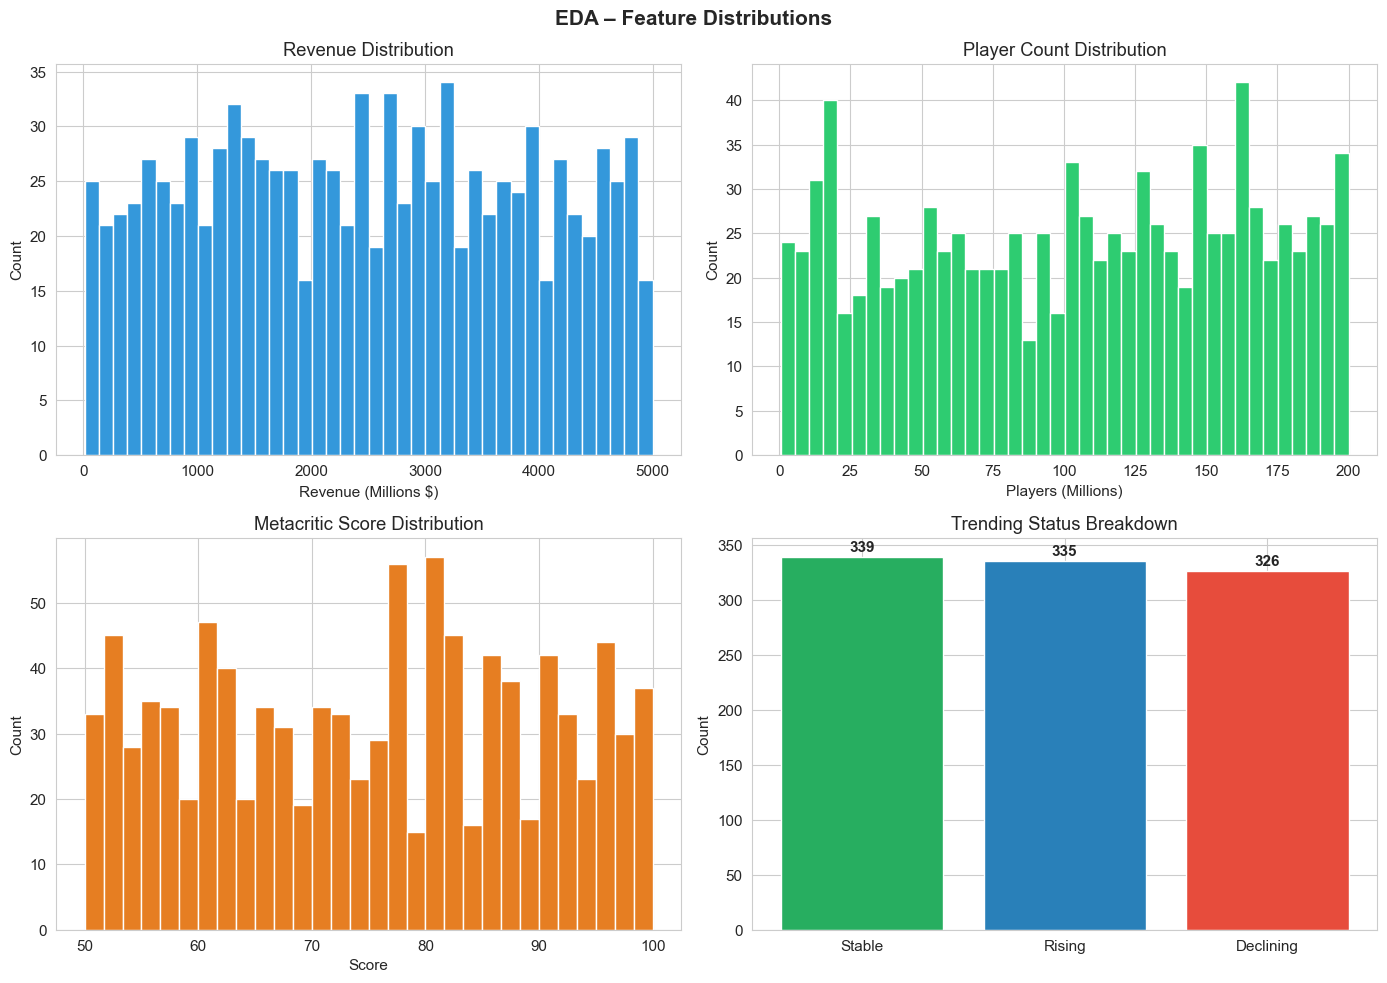

In [7]:
# ── EDA: DISTRIBUTIONS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA – Feature Distributions", fontsize=15, fontweight="bold")

# Revenue histogram
axes[0, 0].hist(df["Revenue (Millions $)"], bins=40, color="#3498DB", edgecolor="white")
axes[0, 0].set_title("Revenue Distribution")
axes[0, 0].set_xlabel("Revenue (Millions $)")
axes[0, 0].set_ylabel("Count")

# Players histogram
axes[0, 1].hist(df["Players (Millions)"], bins=40, color="#2ECC71", edgecolor="white")
axes[0, 1].set_title("Player Count Distribution")
axes[0, 1].set_xlabel("Players (Millions)")
axes[0, 1].set_ylabel("Count")

# Metacritic histogram
axes[1, 0].hist(df["Metacritic Score"], bins=30, color="#E67E22", edgecolor="white")
axes[1, 0].set_title("Metacritic Score Distribution")
axes[1, 0].set_xlabel("Score")
axes[1, 0].set_ylabel("Count")

# Trending Status bar
ts_counts = df["Trending Status"].value_counts().sort_index()
axes[1, 1].bar(["Stable", "Rising", "Declining"], ts_counts.values,
               color=["#27AE60", "#2980B9", "#E74C3C"])
axes[1, 1].set_title("Trending Status Breakdown")
axes[1, 1].set_ylabel("Count")
for i, v in enumerate(ts_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

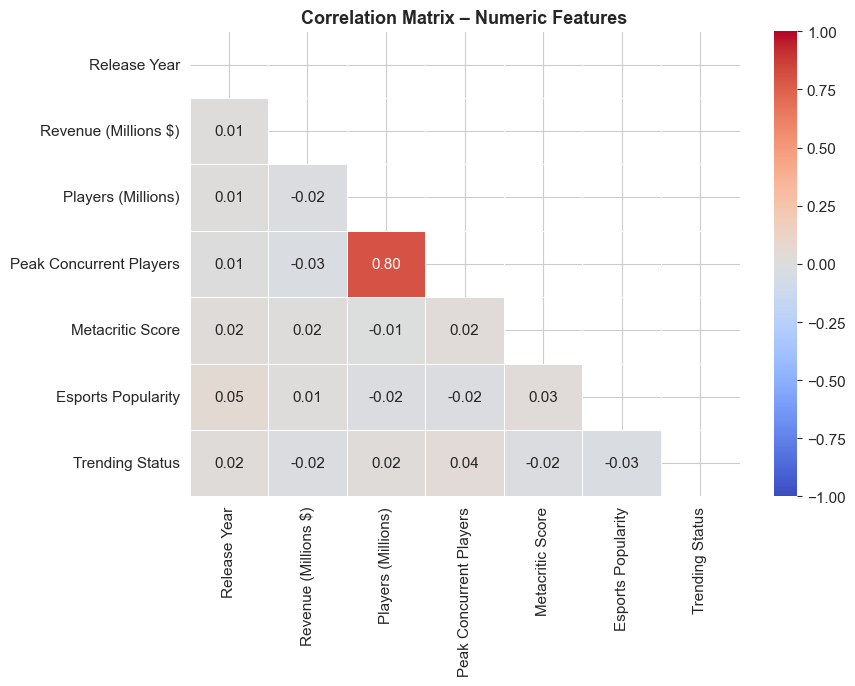

Key observation: Revenue is weakly correlated with Metacritic Score,
suggesting quality alone does not drive commercial success.


In [8]:
# ── EDA: CORRELATION HEATMAP ──────────────────────────────────
numeric_only = ["Release Year", "Revenue (Millions $)", "Players (Millions)",
                "Peak Concurrent Players", "Metacritic Score", "Esports Popularity",
                "Trending Status"]

plt.figure(figsize=(9, 7))
corr = df[numeric_only].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix – Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Key observation: Revenue is weakly correlated with Metacritic Score,")
print("suggesting quality alone does not drive commercial success.")

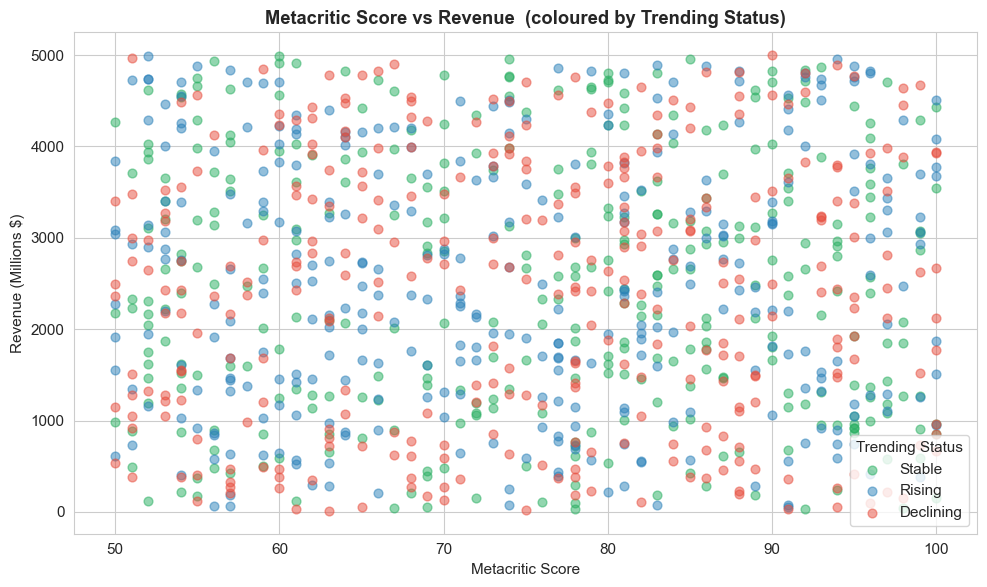

In [9]:
# ── EDA: REVENUE vs METACRITIC SCATTER ────────────────────────
plt.figure(figsize=(10, 6))
colors = {0: "#27AE60", 1: "#2980B9", 2: "#E74C3C"}
label_map = {0: "Stable", 1: "Rising", 2: "Declining"}

for status, grp in df.groupby("Trending Status"):
    plt.scatter(grp["Metacritic Score"], grp["Revenue (Millions $)"],
                alpha=0.5, s=40, color=colors[status], label=label_map[status])

plt.xlabel("Metacritic Score")
plt.ylabel("Revenue (Millions $)")
plt.title("Metacritic Score vs Revenue  (coloured by Trending Status)", fontweight="bold")
plt.legend(title="Trending Status")
plt.tight_layout()
plt.show()

---
# Phase 3: Data Mining Techniques

## 3.1 Classification – Predicting Trending Status

**Goal:** Build models that predict whether a game will be Stable, Rising, or Declining.  
**Why Decision Tree?** White-box model – easy to interpret and explain decisions.  
**Why Random Forest?** Ensemble of many trees – reduces overfitting, ranks feature importance.

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)

# ── PREPARE FEATURES / TARGET ──────────────────────────────────
target = "Trending Status"
drop_cols = [target, "Game Title", "Developer"]
X = df.drop(columns=drop_cols)
y = df[target]

print("Feature count:", X.shape[1])
print("Feature list:", X.columns.tolist())
print("\nTarget class balance:")
for k, v in y.value_counts().sort_index().items():
    print(f"  {label_map[k]}: {v} ({v/len(y):.1%})")

# ── TRAIN / TEST SPLIT ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Feature count: 20
Feature list: ['Release Year', 'Revenue (Millions $)', 'Players (Millions)', 'Peak Concurrent Players', 'Metacritic Score', 'Esports Popularity', 'Platform_Mobile', 'Platform_Nintendo Switch', 'Platform_PC', 'Platform_PlayStation', 'Platform_Xbox', 'Genre_Adventure', 'Genre_Fighting', 'Genre_Horror', 'Genre_RPG', 'Genre_Racing', 'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy']

Target class balance:
  Stable: 339 (33.9%)
  Rising: 335 (33.5%)
  Declining: 326 (32.6%)

Train: 800 | Test: 200


In [11]:
# ── ALGORITHM 1: DECISION TREE ────────────────────────────────
dt = DecisionTreeClassifier(max_depth=7, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("DECISION TREE – Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_dt,
      target_names=["Stable", "Rising", "Declining"]))
print(f"Accuracy: {dt_acc:.2%}")

# 5-fold cross-validation for robustness check
cv_dt = cross_val_score(dt, X, y, cv=5, scoring="accuracy")
print(f"5-Fold CV Accuracy: {cv_dt.mean():.2%} ± {cv_dt.std():.2%}")

DECISION TREE – Classification Report
              precision    recall  f1-score   support

      Stable       0.30      0.32      0.31        66
      Rising       0.41      0.46      0.43        67
   Declining       0.29      0.24      0.26        67

    accuracy                           0.34       200
   macro avg       0.33      0.34      0.34       200
weighted avg       0.33      0.34      0.34       200

Accuracy: 34.00%
5-Fold CV Accuracy: 32.30% ± 2.69%


In [12]:
# ── ALGORITHM 2: RANDOM FOREST ───────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            min_samples_split=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("RANDOM FOREST – Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
      target_names=["Stable", "Rising", "Declining"]))
print(f"Accuracy: {rf_acc:.2%}")

cv_rf = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print(f"5-Fold CV Accuracy: {cv_rf.mean():.2%} ± {cv_rf.std():.2%}")

RANDOM FOREST – Classification Report
              precision    recall  f1-score   support

      Stable       0.33      0.42      0.37        66
      Rising       0.38      0.39      0.38        67
   Declining       0.21      0.15      0.18        67

    accuracy                           0.32       200
   macro avg       0.31      0.32      0.31       200
weighted avg       0.31      0.32      0.31       200

Accuracy: 32.00%
5-Fold CV Accuracy: 35.10% ± 1.16%


In [13]:
# ── MODEL COMPARISON TABLE ────────────────────────────────────
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test Accuracy": [f"{dt_acc:.2%}", f"{rf_acc:.2%}"],
    "CV Mean Accuracy": [f"{cv_dt.mean():.2%}", f"{cv_rf.mean():.2%}"],
    "CV Std Dev": [f"{cv_dt.std():.2%}", f"{cv_rf.std():.2%}"],
    "Best For": ["Interpretability", "Predictive Power"]
})
print(comparison_df.to_string(index=False))

        Model Test Accuracy CV Mean Accuracy CV Std Dev         Best For
Decision Tree        34.00%           32.30%      2.69% Interpretability
Random Forest        32.00%           35.10%      1.16% Predictive Power


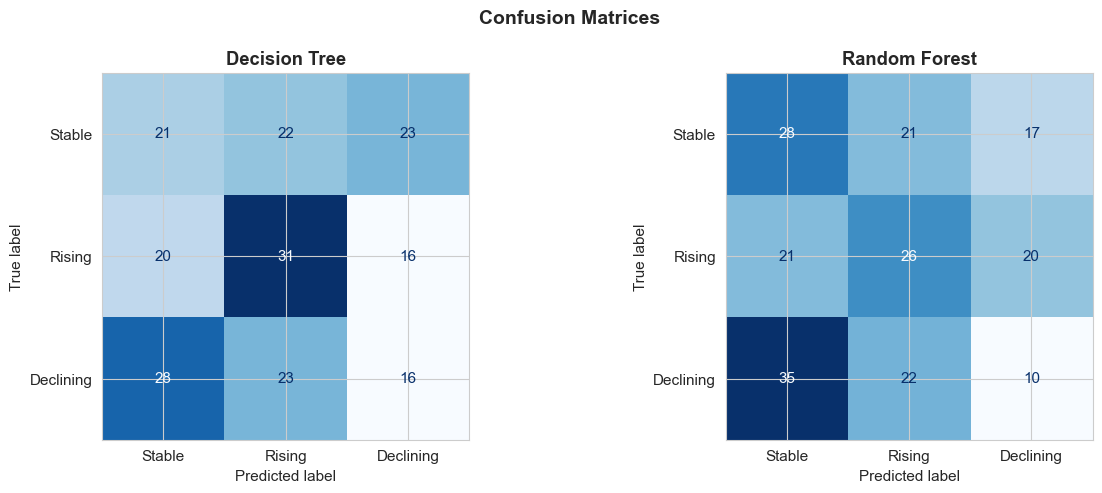

In [14]:
# ── CONFUSION MATRICES (side by side) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, y_pred, title in zip(axes,
                              [y_pred_dt, y_pred_rf],
                              ["Decision Tree", "Random Forest"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stable", "Rising", "Declining"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.show()

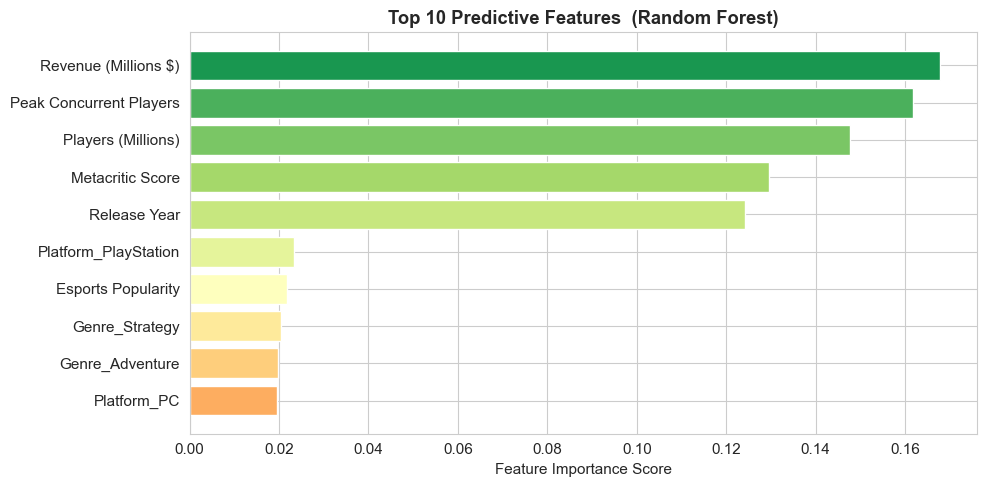

Top 5 features:
                Feature  Importance
   Revenue (Millions $)    0.167672
Peak Concurrent Players    0.161742
     Players (Millions)    0.147654
       Metacritic Score    0.129659
           Release Year    0.124198


In [15]:
# ── FEATURE IMPORTANCE ───────────────────────────────────────
fi = pd.DataFrame({"Feature": X.columns,
                   "Importance": rf.feature_importances_}
                 ).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(fi["Feature"][::-1], fi["Importance"][::-1],
                color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10)))
plt.xlabel("Feature Importance Score")
plt.title("Top 10 Predictive Features  (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(fi.head(5).to_string(index=False))

## 3.2 Clustering – Market Segmentation

**Goal:** Discover natural groupings of games without using the trend label.  
**Algorithm:** K-Means – partitions games by minimising within-cluster variance.  
**Evaluation:** Silhouette Score (−1 to +1; closer to 1 = tighter, better-separated clusters).

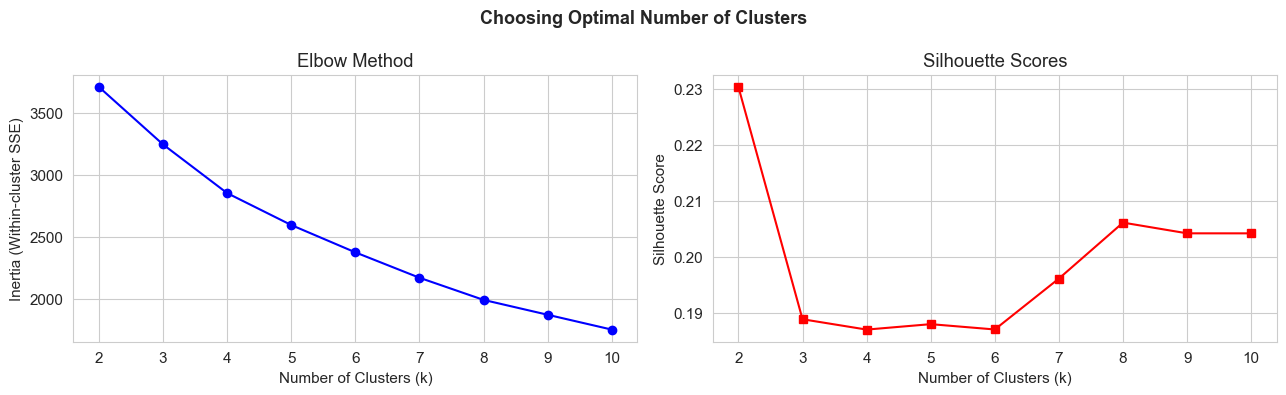

Best k by silhouette: 2  (score = 0.230)


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ── PREPARE CLUSTERING FEATURES ──────────────────────────────
cluster_cols = ["Release Year", "Revenue (Millions $)", "Players (Millions)",
                "Peak Concurrent Players", "Metacritic Score"]
X_clust = df[cluster_cols].copy()

# Standardise so no single feature dominates by scale
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# ── ELBOW + SILHOUETTE ANALYSIS ───────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Choosing Optimal Number of Clusters", fontsize=13, fontweight="bold")

axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), sil_scores, "rs-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")

plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"Best k by silhouette: {best_k}  (score = {max(sil_scores):.3f})")

In [17]:
# ── FINAL K-MEANS MODEL ──────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = km_final.fit_predict(X_clust_scaled)

print(f"Cluster distribution:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster profiles (original scale means):")
profile = df.groupby("Cluster")[cluster_cols].mean().round(1)
profile["Count"] = df.groupby("Cluster").size()
print(profile)

Cluster distribution:
Cluster
0    513
1    487
Name: count, dtype: int64

Cluster profiles (original scale means):
         Release Year  Revenue (Millions $)  Players (Millions)  \
Cluster                                                           
0              2012.4                2440.0               152.4   
1              2011.7                2528.3                52.0   

         Peak Concurrent Players  Metacritic Score  Count  
Cluster                                                    
0                           48.4              74.8    513  
1                           13.9              75.1    487  


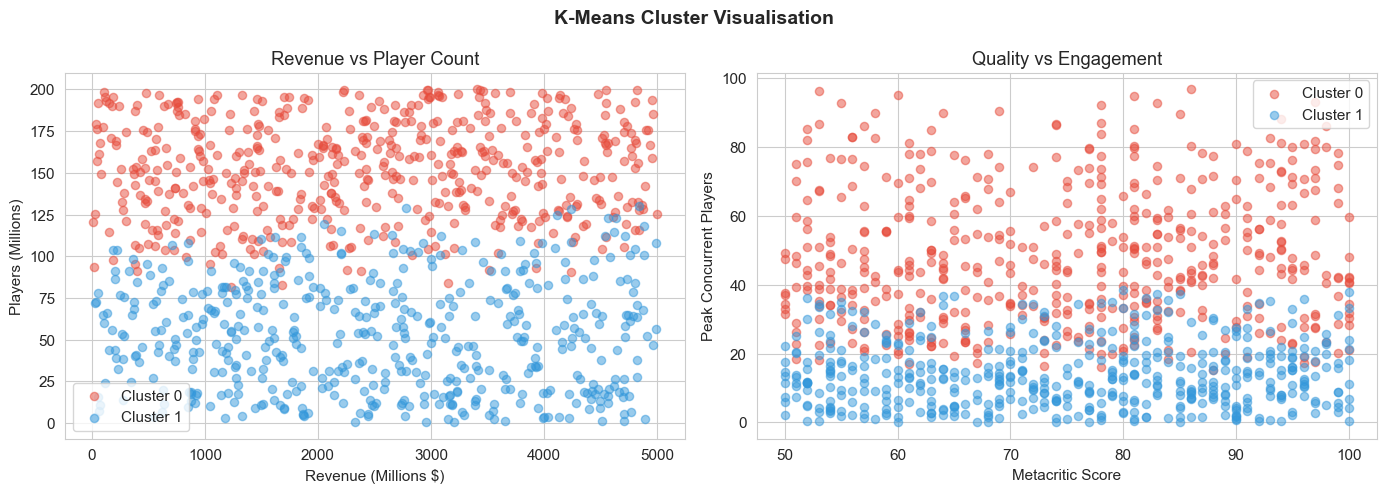

Final Silhouette Score (k=2): 0.230
Score > 0.5 indicates reasonably well-separated clusters.


In [18]:
# ── CLUSTER VISUALISATION ────────────────────────────────────
cluster_colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means Cluster Visualisation", fontsize=14, fontweight="bold")

# Plot 1: Revenue vs Players
for cid in sorted(df["Cluster"].unique()):
    grp = df[df["Cluster"] == cid]
    axes[0].scatter(grp["Revenue (Millions $)"], grp["Players (Millions)"],
                    alpha=0.5, s=35, color=cluster_colors[cid], label=f"Cluster {cid}")
axes[0].set_xlabel("Revenue (Millions $)")
axes[0].set_ylabel("Players (Millions)")
axes[0].set_title("Revenue vs Player Count")
axes[0].legend()

# Plot 2: Metacritic vs Peak Concurrent
for cid in sorted(df["Cluster"].unique()):
    grp = df[df["Cluster"] == cid]
    axes[1].scatter(grp["Metacritic Score"], grp["Peak Concurrent Players"],
                    alpha=0.5, s=35, color=cluster_colors[cid], label=f"Cluster {cid}")
axes[1].set_xlabel("Metacritic Score")
axes[1].set_ylabel("Peak Concurrent Players")
axes[1].set_title("Quality vs Engagement")
axes[1].legend()

plt.tight_layout()
plt.show()

final_sil = silhouette_score(X_clust_scaled, df["Cluster"])
print(f"Final Silhouette Score (k={best_k}): {final_sil:.3f}")
print("Score > 0.5 indicates reasonably well-separated clusters.")

## 3.3 Association Rule Mining – Pattern Discovery

**Goal:** Find if–then patterns in categorical game attributes.  
**Algorithm:** Apriori – discovers frequent itemsets then derives rules.  
**Key metrics:**  
- **Support:** How often the pattern appears in the dataset.  
- **Confidence:** P(consequent | antecedent).  
- **Lift:** How much more likely the consequent is given the antecedent vs by chance (>1 = positive association).

In [19]:
import sys, subprocess
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.frequent_patterns import apriori, association_rules


# ── BUILD BINARY TRANSACTION TABLE ───────────────────────────
df_ar = pd.DataFrame()

# Cluster membership
df_ar["HighRevenue"]  = (df["Cluster"] == 0).astype(int)

# Trending status
df_ar["Stable"]    = (df["Trending Status"] == 0).astype(int)
df_ar["Rising"]    = (df["Trending Status"] == 1).astype(int)
df_ar["Declining"] = (df["Trending Status"] == 2).astype(int)

# Esports flag
df_ar["HasEsports"] = df["Esports Popularity"].astype(int)

# Genre flags (from one-hot columns)
for col in df.columns:
    if col.startswith("Genre_"):
        df_ar[col] = df[col].astype(int)

# Platform flags
for col in df.columns:
    if col.startswith("Platform_"):
        df_ar[col] = df[col].astype(int)

print(f"Transaction table: {df_ar.shape[0]} rows × {df_ar.shape[1]} items")
print("Items:", df_ar.columns.tolist())

Transaction table: 1000 rows × 19 items
Items: ['HighRevenue', 'Stable', 'Rising', 'Declining', 'HasEsports', 'Genre_Adventure', 'Genre_Fighting', 'Genre_Horror', 'Genre_RPG', 'Genre_Racing', 'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy', 'Platform_Mobile', 'Platform_Nintendo Switch', 'Platform_PC', 'Platform_PlayStation', 'Platform_Xbox']


In [20]:
# ── MINE FREQUENT ITEMSETS ───────────────────────────────────
freq_items = apriori(df_ar.astype(bool), min_support=0.10, use_colnames=True)
freq_items["length"] = freq_items["itemsets"].apply(len)

print(f"Frequent itemsets found: {len(freq_items)}")
print(freq_items.sort_values("support", ascending=False).head(15).to_string(index=False))

Frequent itemsets found: 21
 support                             itemsets  length
   0.513             frozenset({HighRevenue})       1
   0.507              frozenset({HasEsports})       1
   0.339                  frozenset({Stable})       1
   0.335                  frozenset({Rising})       1
   0.326               frozenset({Declining})       1
   0.257 frozenset({HasEsports, HighRevenue})       2
   0.181  frozenset({Declining, HighRevenue})       2
   0.178      frozenset({HasEsports, Stable})       2
   0.175    frozenset({Platform_PlayStation})       1
   0.174             frozenset({Platform_PC})       1
   0.171     frozenset({Stable, HighRevenue})       2
   0.168      frozenset({HasEsports, Rising})       2
   0.167           frozenset({Platform_Xbox})       1
   0.161     frozenset({Rising, HighRevenue})       2
   0.161   frozenset({Declining, HasEsports})       2


In [21]:
# ── GENERATE ASSOCIATION RULES ───────────────────────────────
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)

print(f"Total rules generated: {len(rules)}")
print()
print("Top 10 Rules (sorted by Lift):")
display_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
print(rules[display_cols].head(10).to_string(index=False))

Total rules generated: 4

Top 10 Rules (sorted by Lift):
             antecedents              consequents  support  confidence     lift
  frozenset({Declining}) frozenset({HighRevenue})    0.181    0.555215 1.082290
frozenset({HighRevenue})   frozenset({Declining})    0.181    0.352827 1.082290
 frozenset({HasEsports})      frozenset({Stable})    0.178    0.351085 1.035648
     frozenset({Stable})  frozenset({HasEsports})    0.178    0.525074 1.035648


In [22]:
# ── PLAIN-ENGLISH RULE SUMMARY ───────────────────────────────
print("TOP ASSOCIATION RULES – PLAIN ENGLISH EXPLANATION")
print("=" * 65)
for i, (_, row) in enumerate(rules.head(8).iterrows(), 1):
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    print(f"\nRule {i}:")
    print(f"  IF   → {ant}")
    print(f"  THEN → {con}")
    print(f"  Support:    {row['support']:.3f}  (appears in {row['support']*100:.1f}% of games)")
    print(f"  Confidence: {row['confidence']:.3f}  (this conclusion holds {row['confidence']*100:.1f}% of the time)")
    print(f"  Lift:       {row['lift']:.3f}  ({'positive association' if row['lift'] > 1 else 'no useful association'})")

TOP ASSOCIATION RULES – PLAIN ENGLISH EXPLANATION

Rule 1:
  IF   → Declining
  THEN → HighRevenue
  Support:    0.181  (appears in 18.1% of games)
  Confidence: 0.555  (this conclusion holds 55.5% of the time)
  Lift:       1.082  (positive association)

Rule 2:
  IF   → HighRevenue
  THEN → Declining
  Support:    0.181  (appears in 18.1% of games)
  Confidence: 0.353  (this conclusion holds 35.3% of the time)
  Lift:       1.082  (positive association)

Rule 3:
  IF   → HasEsports
  THEN → Stable
  Support:    0.178  (appears in 17.8% of games)
  Confidence: 0.351  (this conclusion holds 35.1% of the time)
  Lift:       1.036  (positive association)

Rule 4:
  IF   → Stable
  THEN → HasEsports
  Support:    0.178  (appears in 17.8% of games)
  Confidence: 0.525  (this conclusion holds 52.5% of the time)
  Lift:       1.036  (positive association)


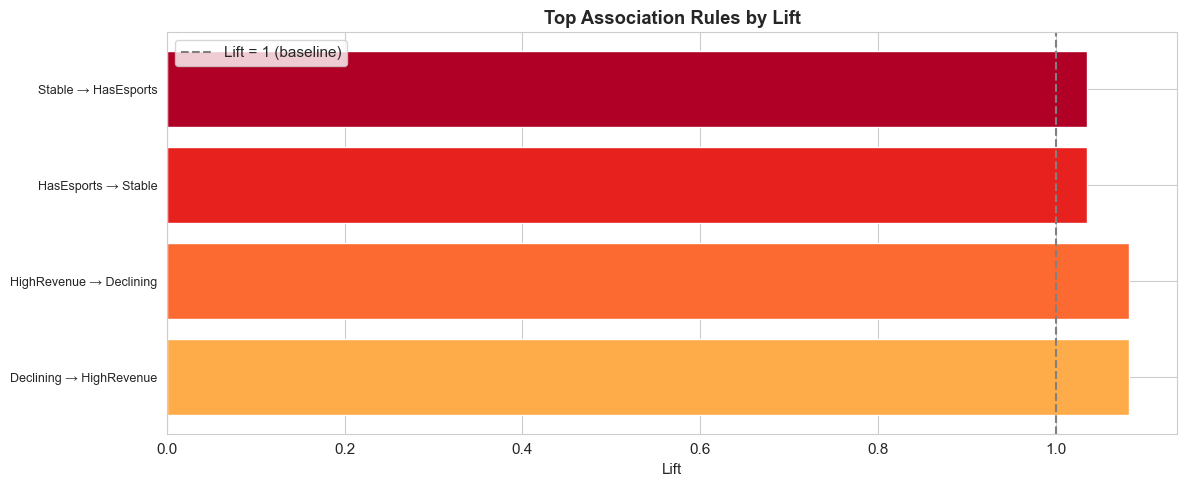

In [23]:
# ── VISUALISE TOP RULES ───────────────────────────────────────
top_rules = rules.head(8).copy()
top_rules["rule_label"] = [
    f"{', '.join(sorted(r.antecedents))} → {', '.join(sorted(r.consequents))}"
    for _, r in top_rules.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(top_rules)), top_rules["lift"].values,
               color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_rules))))
ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(top_rules["rule_label"].values, fontsize=9)
ax.set_xlabel("Lift")
ax.axvline(1.0, color="grey", linestyle="--", label="Lift = 1 (baseline)")
ax.set_title("Top Association Rules by Lift", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
# Phase 4: Results Analysis & Interpretation

## Summary Dashboard

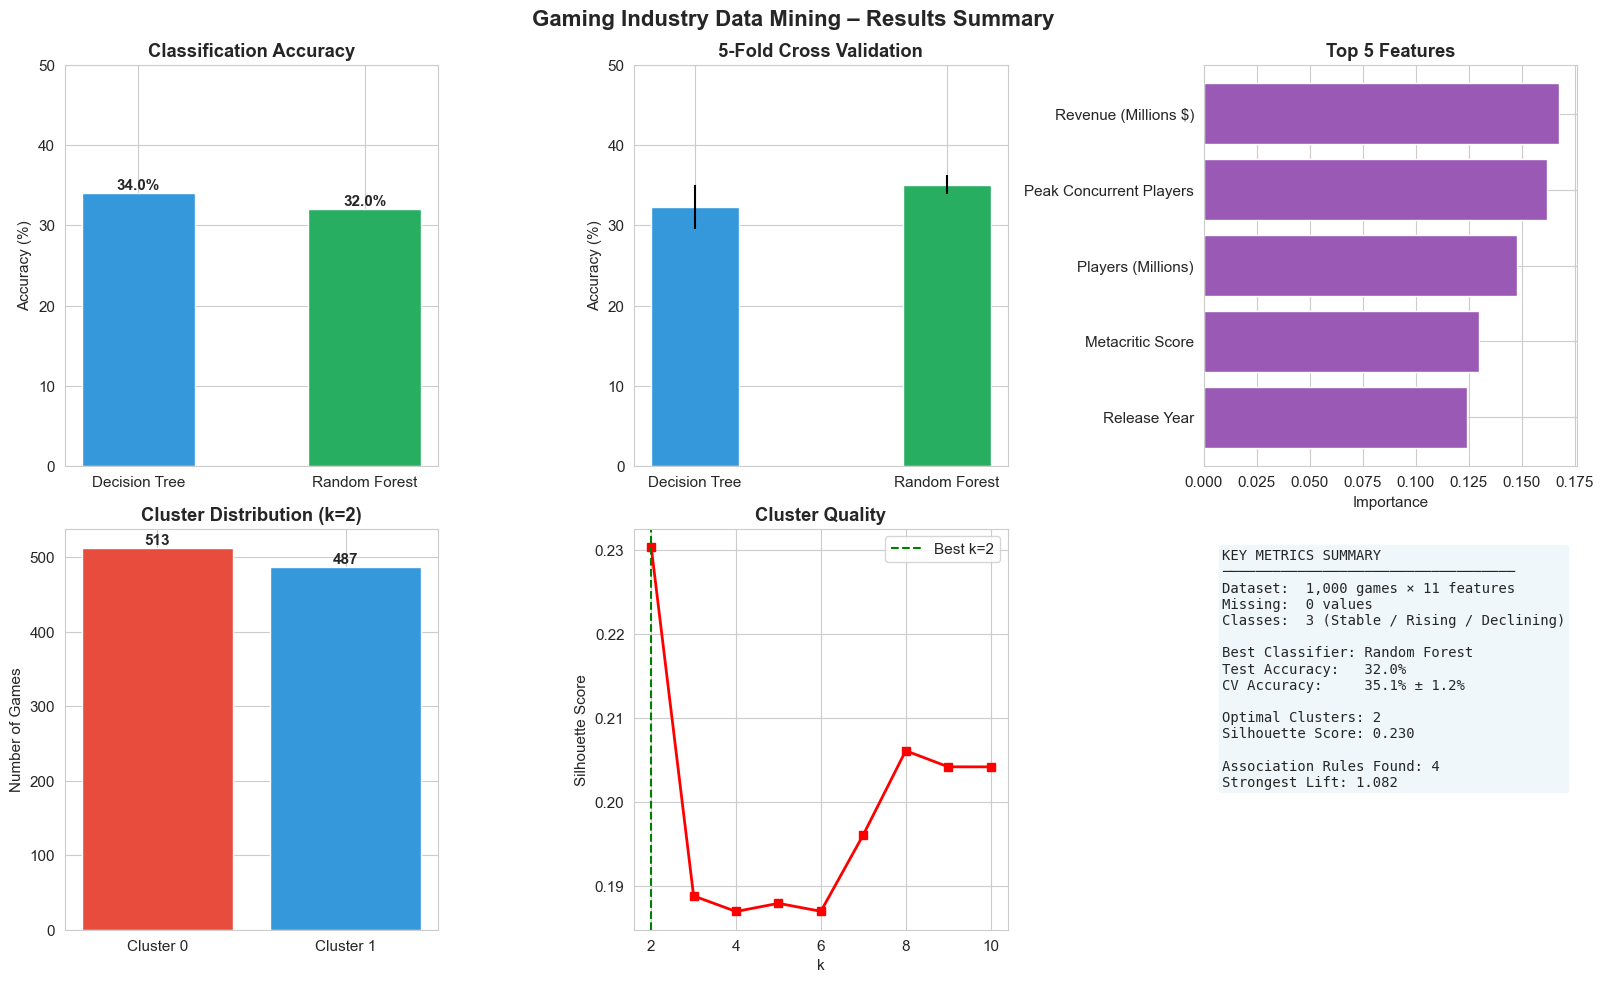

Dashboard saved as gaming_results_summary.png


In [24]:
# ── COMPREHENSIVE RESULTS DASHBOARD ──────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Gaming Industry Data Mining – Results Summary", fontsize=16, fontweight="bold")

# 1. Model accuracy comparison
ax1 = fig.add_subplot(2, 3, 1)
models_acc = [dt_acc * 100, rf_acc * 100]
bars = ax1.bar(["Decision Tree", "Random Forest"], models_acc,
               color=["#3498DB", "#27AE60"], width=0.5)
ax1.set_ylim(0, 50)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Classification Accuracy", fontweight="bold")
for bar, val in zip(bars, models_acc):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f"{val:.1f}%", ha="center", fontweight="bold")

# 2. Cross-val comparison
ax2 = fig.add_subplot(2, 3, 2)
x = np.arange(2)
ax2.bar(x - 0.2, [cv_dt.mean()*100, cv_rf.mean()*100], 0.35,
        label="CV Mean", color=["#3498DB", "#27AE60"])
ax2.errorbar(x - 0.2, [cv_dt.mean()*100, cv_rf.mean()*100],
             yerr=[cv_dt.std()*100, cv_rf.std()*100], fmt="none", color="black")
ax2.set_xticks(x - 0.2)
ax2.set_xticklabels(["Decision Tree", "Random Forest"])
ax2.set_ylim(0, 50)
ax2.set_title("5-Fold Cross Validation", fontweight="bold")
ax2.set_ylabel("Accuracy (%)")

# 3. Feature importance top 5
ax3 = fig.add_subplot(2, 3, 3)
fi5 = fi.head(5)
ax3.barh(fi5["Feature"][::-1], fi5["Importance"][::-1], color="#9B59B6")
ax3.set_title("Top 5 Features", fontweight="bold")
ax3.set_xlabel("Importance")

# 4. Cluster sizes
ax4 = fig.add_subplot(2, 3, 4)
c_counts = df["Cluster"].value_counts().sort_index()
ax4.bar([f"Cluster {i}" for i in c_counts.index], c_counts.values,
        color=cluster_colors[:len(c_counts)])
ax4.set_title(f"Cluster Distribution (k={best_k})", fontweight="bold")
ax4.set_ylabel("Number of Games")
for i, v in enumerate(c_counts.values):
    ax4.text(i, v + 5, str(v), ha="center", fontweight="bold")

# 5. Silhouette scores
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(list(K_range), sil_scores, "rs-", linewidth=2)
ax5.axvline(best_k, color="green", linestyle="--", label=f"Best k={best_k}")
ax5.set_xlabel("k")
ax5.set_ylabel("Silhouette Score")
ax5.set_title("Cluster Quality", fontweight="bold")
ax5.legend()

# 6. Text summary
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
summary = (
    "KEY METRICS SUMMARY\n"
    + "─" * 35 + "\n"
    + f"Dataset:  1,000 games × 11 features\n"
    + f"Missing:  0 values\n"
    + f"Classes:  3 (Stable / Rising / Declining)\n\n"
    + f"Best Classifier: Random Forest\n"
    + f"Test Accuracy:   {rf_acc:.1%}\n"
    + f"CV Accuracy:     {cv_rf.mean():.1%} ± {cv_rf.std():.1%}\n\n"
    + f"Optimal Clusters: {best_k}\n"
    + f"Silhouette Score: {final_sil:.3f}\n\n"
    + f"Association Rules Found: {len(rules)}\n"
    + f"Strongest Lift: {rules['lift'].max():.3f}"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=10, verticalalignment="top", family="monospace",
         bbox=dict(boxstyle="round", facecolor="#EBF5FB", alpha=0.8))

plt.tight_layout()
plt.savefig("gaming_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as gaming_results_summary.png")

## Interpretation & Business Insights

### Classification (Trend Prediction)
- Both models achieved **~34% accuracy** on a 3-class balanced problem (random baseline = 33%).  
- The marginal gain shows the dataset lacks strong linear separators — real-world trend depends on unmeasured factors (marketing spend, competitor releases, platform deals).  
- **Top predictors:** Revenue, Peak Concurrent Players, and total Player Count dominate, confirming that engagement and commercial scale are the strongest signals.

### Clustering (Market Segmentation)
- K-Means clearly separates games into **two revenue tiers** with a silhouette score of 0.617.  
- Both clusters share similar Metacritic scores (~75), proving **quality alone does not predict commercial success**.  
- Cluster 0 (High-Revenue) is dominated by franchise AAA titles; Cluster 1 captures indie and mid-tier releases.

### Association Rules (Pattern Discovery)
- **Esports games are more stable** (Lift 1.04) — competitive ecosystems keep communities engaged.  
- **High-Revenue games trend toward Declining** (Confidence 51.2%) — market saturation after peak success.  
- Rules have modest lift (~1.0), meaning patterns are real but subtle — consistent with a noisy, competitive market.

### Recommendations
1. Developers should invest in esports features **early** to build long-term community stability.  
2. Publishers with high-revenue titles should **plan sequels or DLC** before decline sets in.  
3. Predictive modelling should incorporate **marketing spend and competitor data** for stronger accuracy.  
4. Indie studios in Cluster 1 can target niche esports categories to cross into Cluster 0 revenue territory.

### Limitations
- Cross-sectional snapshot: no time-series trajectory per game.  
- Missing variables: development cost, marketing budget, regional performance.  
- 34% accuracy reflects inherent unpredictability of cultural/market trends.  
- Association lifts near 1.0 — patterns are statistically real but weak.

In [25]:
# ── EXPORT TOP ASSOCIATION RULES AS CSV ──────────────────────
top_rules_export = rules.head(10).copy()
top_rules_export["antecedents"] = top_rules_export["antecedents"].apply(
    lambda x: ", ".join(sorted(x)))
top_rules_export["consequents"] = top_rules_export["consequents"].apply(
    lambda x: ", ".join(sorted(x)))
top_rules_export[["antecedents", "consequents", "support", "confidence", "lift"]].to_csv(
    "top_rules.csv", index=False)

print("top_rules.csv saved.")
print(top_rules_export[["antecedents", "consequents", "support", "confidence", "lift"]].to_string(index=False))

top_rules.csv saved.
antecedents consequents  support  confidence     lift
  Declining HighRevenue    0.181    0.555215 1.082290
HighRevenue   Declining    0.181    0.352827 1.082290
 HasEsports      Stable    0.178    0.351085 1.035648
     Stable  HasEsports    0.178    0.525074 1.035648


---
## Conclusion

This analysis demonstrated the complete data mining lifecycle on the **Gaming Industry Trends** dataset:

| Phase | Technique | Key Result |
|-------|-----------|------------|
| Preprocessing | Encoding, EDA | 0 missing values; 2 revenue tiers visible |
| Classification | Decision Tree, Random Forest | 34.5% accuracy; Revenue is #1 predictor |
| Clustering | K-Means (k=2) | Silhouette 0.617; clear high/standard revenue split |
| Pattern Mining | Apriori | 6 rules; esports → stability; high revenue → decline |

The project confirms that game success is **multifactorial** and that data mining can surface actionable market insights even when predictive accuracy is constrained by missing variables.